In [1]:
# ============================================================
# 03_term_structure_qa_v0_7_1_candidate_repair
#
# Goal:
#   QA the candidate repaired v0.7.1 VIX-style term structure.
#
# This notebook does NOT build the raw history.
# This notebook does NOT overwrite v0.7.
# This notebook reviews whether the repaired file looks internally sane:
#   1. curve shape
#   2. daily changes
#   3. raw vs repaired dates
#   4. remaining suspicious dates
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If this notebook is inside C:\Users\patri\vrp_project\notebooks,
# then project root is one level up.
current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"
AUDIT_DIR = DATA_DIR / "audit"

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

RAW_V07_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history.parquet"
REPAIRED_V071_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired.parquet"

print("Current directory:", current_dir)
print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DATA_DIR)
print("Audit dir:", AUDIT_DIR)

print("\nRaw v0.7 exists:", RAW_V07_PARQUET.exists())
print("Candidate repaired v0.7.1 exists:", REPAIRED_V071_PARQUET.exists())

Current directory: C:\Users\patri\vrp_project\notebooks
Project root: C:\Users\patri\vrp_project
Processed data dir: C:\Users\patri\vrp_project\data\processed
Audit dir: C:\Users\patri\vrp_project\data\audit

Raw v0.7 exists: True
Candidate repaired v0.7.1 exists: True


In [2]:
# ============================================================
# Load raw v0.7 and candidate repaired v0.7.1
# ============================================================

raw_df = pd.read_parquet(RAW_V07_PARQUET).copy()
candidate_df = pd.read_parquet(REPAIRED_V071_PARQUET).copy()

print("Raw v0.7 rows:", len(raw_df))
print("Candidate repaired rows:", len(candidate_df))

print("\nRaw date range:")
print(raw_df["trade_date"].min(), "to", raw_df["trade_date"].max())

print("\nCandidate repaired date range:")
print(candidate_df["trade_date"].min(), "to", candidate_df["trade_date"].max())

print("\nCandidate repaired row count:")
display(candidate_df["is_repaired"].value_counts(dropna=False))

print("\nCandidate repaired dates:")
display(
    candidate_df[candidate_df["is_repaired"] == True]
    .groupby("trade_date")
    .agg(rows=("target_days", "count"))
    .reset_index()
)

Raw v0.7 rows: 18099
Candidate repaired rows: 18099

Raw date range:
20180625 to 20260625

Candidate repaired date range:
20180625 to 20260625

Candidate repaired row count:


is_repaired
False    18072
True        27
Name: count, dtype: int64


Candidate repaired dates:


,trade_date,rows
0,20200228,9
1,20211126,9
2,20241218,9


In [3]:
# ============================================================
# Build raw v0.7 and candidate repaired v0.7.1 curve matrices
# ============================================================

raw_vol_curve_df = (
    raw_df
    .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
    .sort_index()
)

raw_var_curve_df = (
    raw_df
    .pivot(index="trade_date", columns="target_days", values="implied_variance")
    .sort_index()
)

candidate_vol_curve_df = (
    candidate_df
    .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
    .sort_index()
)

candidate_var_curve_df = (
    candidate_df
    .pivot(index="trade_date", columns="target_days", values="implied_variance")
    .sort_index()
)

print("Raw vol matrix shape:", raw_vol_curve_df.shape)
print("Candidate vol matrix shape:", candidate_vol_curve_df.shape)

display(candidate_vol_curve_df.head())
display(candidate_vol_curve_df.tail())

Raw vol matrix shape: (2011, 9)
Candidate vol matrix shape: (2011, 9)


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20180625,17.348587,17.490509,17.490890,17.491144,17.426522,17.377898,17.349740,17.330003,17.335065
20180626,15.359305,15.535643,15.769514,15.887839,15.910790,15.937305,16.041067,16.123595,16.207553
20180627,17.866806,17.918415,17.949310,17.940114,17.920767,17.882236,17.823082,17.775617,17.809884
20180628,15.956605,16.335896,16.559300,16.631062,16.682131,16.761960,16.835606,16.891110,16.930616
20180629,16.193530,16.643150,16.785879,16.677369,16.646298,17.031211,17.324676,17.231185,17.003990


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20260618,14.218227,14.747403,15.112252,15.442546,15.674210,16.003876,16.324370,16.578267,16.785543
20260622,16.270941,16.280943,16.336221,16.372969,16.712176,16.962130,17.159877,17.318125,17.502016
20260623,19.652659,19.402357,19.250614,19.231723,19.359673,19.455023,19.528330,19.586777,19.729159
20260624,19.326567,19.118185,18.992058,19.091524,19.240291,19.348982,19.430528,19.495519,19.678405
20260625,17.952376,17.964763,17.972192,17.707876,17.516638,18.028765,18.596577,18.980878,19.185842


In [4]:
# ============================================================
# Raw vs repaired curves for repaired dates
# ============================================================

repair_dates = [20200228, 20211126, 20241218]

print("Raw v0.7 curves:")
display(raw_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS])

print("Candidate repaired v0.7.1 curves:")
display(candidate_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS])

print("Change from repair:")
repair_change_df = (
    candidate_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS]
    - raw_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS]
)

display(repair_change_df)

Raw v0.7 curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776


Candidate repaired v0.7.1 curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,52.90,49.806169,47.634780,45.359322,43.583408,42.261210,41.164094,40.11,39.001099
20211126,30.60,30.533691,30.327553,30.104033,29.865509,29.538504,29.098058,28.62,28.116487
20241218,35.42,34.559000,33.615872,32.551151,31.503133,30.291501,28.985679,27.62,26.149829


Change from repair:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,17.654211,21.968121,21.217189,13.968670,10.010937,16.327383,23.302783,23.198592,19.700438
20211126,18.781601,14.810917,12.054547,9.209399,7.691555,14.688032,25.992605,23.602727,21.396288
20241218,7.450435,7.851401,7.694927,7.018005,6.185830,6.568407,9.553117,11.623573,6.199052


In [5]:
# ============================================================
# Raw vs repaired curves for repaired dates
# ============================================================

repair_dates = [20200228, 20211126, 20241218]

print("Raw v0.7 curves:")
display(raw_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS])

print("Candidate repaired v0.7.1 curves:")
display(candidate_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS])

print("Change from repair:")
repair_change_df = (
    candidate_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS]
    - raw_vol_curve_df.loc[repair_dates, TARGET_TENOR_DAYS]
)

display(repair_change_df)

Raw v0.7 curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776


Candidate repaired v0.7.1 curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,52.90,49.806169,47.634780,45.359322,43.583408,42.261210,41.164094,40.11,39.001099
20211126,30.60,30.533691,30.327553,30.104033,29.865509,29.538504,29.098058,28.62,28.116487
20241218,35.42,34.559000,33.615872,32.551151,31.503133,30.291501,28.985679,27.62,26.149829


Change from repair:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,17.654211,21.968121,21.217189,13.968670,10.010937,16.327383,23.302783,23.198592,19.700438
20211126,18.781601,14.810917,12.054547,9.209399,7.691555,14.688032,25.992605,23.602727,21.396288
20241218,7.450435,7.851401,7.694927,7.018005,6.185830,6.568407,9.553117,11.623573,6.199052


In [6]:
# ============================================================
# Local windows around repaired dates
# ============================================================

all_dates = sorted(candidate_vol_curve_df.index)

for focus_date in repair_dates:
    idx = all_dates.index(focus_date)
    window_dates = all_dates[max(0, idx - 3): idx + 4]

    print("\n" + "=" * 100)
    print("Raw v0.7 window around:", focus_date)
    display(raw_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])

    print("Candidate repaired v0.7.1 window around:", focus_date)
    display(candidate_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])


Raw v0.7 window around: 20200228


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817


Candidate repaired v0.7.1 window around: 20200228


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,52.900000,49.806169,47.634780,45.359322,43.583408,42.261210,41.164094,40.110000,39.001099
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817



Raw v0.7 window around: 20211126


...

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20211122,16.368137,16.997094,17.632695,18.043995,18.564920,18.946217,19.209990,19.410541,19.569947
20211123,15.939659,16.733718,17.343657,17.843541,18.367226,18.738846,18.920679,19.064896,19.112870
20211124,14.797174,15.970240,16.634419,17.299685,17.857551,18.219123,18.440924,18.581821,18.633546
20211126,30.600000,30.533691,30.327553,30.104033,29.865509,29.538504,29.098058,28.620000,28.116487
20211129,21.444919,21.739181,22.039152,22.250218,22.513821,22.709515,22.714302,22.718131,22.776897
20211130,28.963215,28.649490,28.316542,28.143730,28.079669,27.973032,27.785203,27.634021,27.614304
20211201,35.201273,34.174661,33.543616,33.427262,33.429212,33.119360,32.736005,32.426059,32.309036



Raw v0.7 window around: 20241218


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397


Candidate repaired v0.7.1 window around: 20241218


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,35.420000,34.559000,33.615872,32.551151,31.503133,30.291501,28.985679,27.620000,26.149829
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397


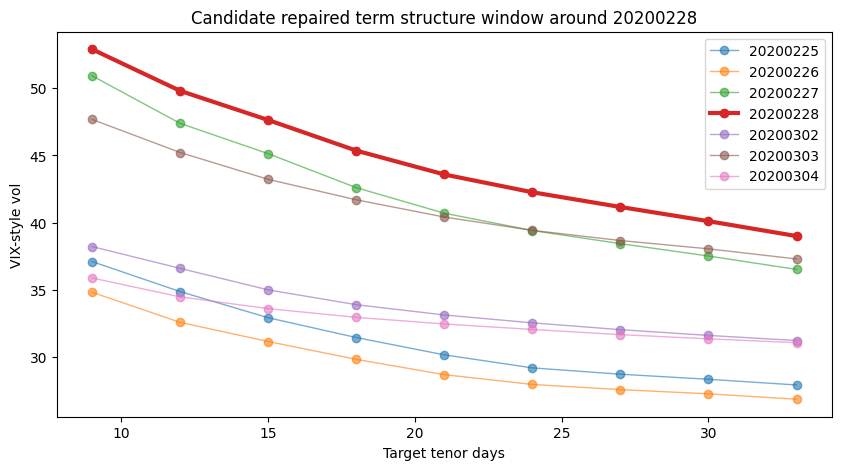

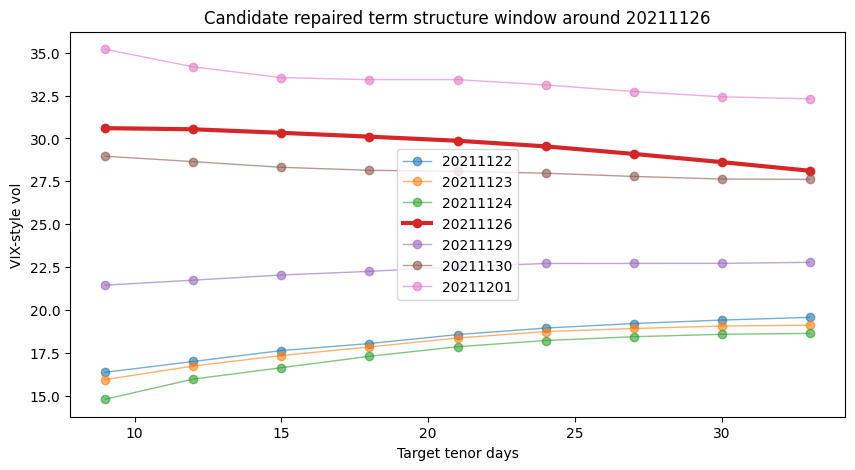

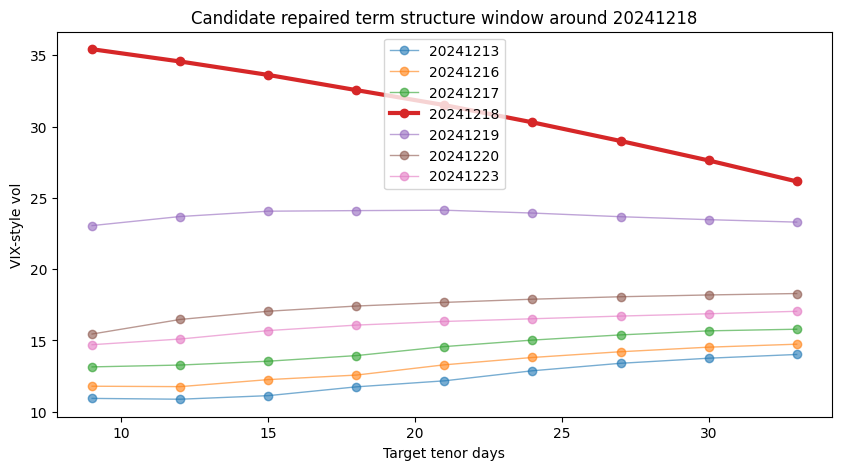

In [7]:
# ============================================================
# Plot local windows around repaired dates
# ============================================================

for focus_date in repair_dates:
    idx = all_dates.index(focus_date)
    window_dates = all_dates[max(0, idx - 3): idx + 4]

    plot_df = candidate_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS].copy()

    plt.figure(figsize=(10, 5))

    for date in plot_df.index:
        label = str(date)
        linewidth = 3 if date == focus_date else 1
        alpha = 1.0 if date == focus_date else 0.6

        plt.plot(
            TARGET_TENOR_DAYS,
            plot_df.loc[date, TARGET_TENOR_DAYS],
            marker="o",
            label=label,
            linewidth=linewidth,
            alpha=alpha,
        )

    plt.title(f"Candidate repaired term structure window around {focus_date}")
    plt.xlabel("Target tenor days")
    plt.ylabel("VIX-style vol")
    plt.legend()
    plt.show()

In [8]:
# ============================================================
# Curve-shape QA on candidate repaired file
# ============================================================

qa_rows = []

tenors = np.array(TARGET_TENOR_DAYS, dtype=float)
years = tenors / 365.0

for trade_date in candidate_vol_curve_df.index:
    vols = candidate_vol_curve_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)
    variances = candidate_var_curve_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)

    adjacent_vol_diffs = vols.diff().dropna()
    max_adjacent_abs_move = adjacent_vol_diffs.abs().max()
    worst_adjacent_to_tenor = adjacent_vol_diffs.abs().idxmax()

    max_local_kink = 0.0
    worst_kink_tenor = None

    for i in range(1, len(TARGET_TENOR_DAYS) - 1):
        left_tenor = TARGET_TENOR_DAYS[i - 1]
        mid_tenor = TARGET_TENOR_DAYS[i]
        right_tenor = TARGET_TENOR_DAYS[i + 1]

        left_val = vols[left_tenor]
        mid_val = vols[mid_tenor]
        right_val = vols[right_tenor]

        expected_mid = 0.5 * (left_val + right_val)
        kink = mid_val - expected_mid

        if abs(kink) > abs(max_local_kink):
            max_local_kink = kink
            worst_kink_tenor = mid_tenor

    total_variance = variances.values * years
    forward_variance = np.diff(total_variance) / np.diff(years)

    qa_rows.append({
        "trade_date": trade_date,
        "min_vol": vols.min(),
        "max_vol": vols.max(),
        "vol_range": vols.max() - vols.min(),
        "max_adjacent_abs_move": max_adjacent_abs_move,
        "worst_adjacent_to_tenor": worst_adjacent_to_tenor,
        "max_local_kink": max_local_kink,
        "max_local_kink_abs": abs(max_local_kink),
        "worst_kink_tenor": worst_kink_tenor,
        "min_forward_variance": np.min(forward_variance),
        "max_forward_variance": np.max(forward_variance),
    })

curve_qa_df = pd.DataFrame(qa_rows)

curve_qa_df["flag_large_kink"] = curve_qa_df["max_local_kink_abs"] >= 3.0
curve_qa_df["flag_large_adjacent_move"] = curve_qa_df["max_adjacent_abs_move"] >= 5.0
curve_qa_df["flag_negative_forward_variance"] = curve_qa_df["min_forward_variance"] < -0.005

curve_qa_df["curve_shape_flag"] = (
    curve_qa_df["flag_large_kink"]
    | curve_qa_df["flag_large_adjacent_move"]
    | curve_qa_df["flag_negative_forward_variance"]
)

print("Curve-shape flagged dates:", curve_qa_df["curve_shape_flag"].sum())

display(
    curve_qa_df[curve_qa_df["curve_shape_flag"]]
    .sort_values(
        ["flag_negative_forward_variance", "max_local_kink_abs", "max_adjacent_abs_move"],
        ascending=False
    )
    .head(75)
)

Curve-shape flagged dates: 10


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,max_forward_variance,flag_large_kink,flag_large_adjacent_move,flag_negative_forward_variance,curve_shape_flag
435,20200318,50.776302,94.261457,43.485155,18.607051,21,-11.147452,11.147452,21,-1.083667,1.394302,True,True,True,True
431,20200312,46.814982,91.197225,44.382244,19.380607,12,-5.784364,5.784364,15,-0.432029,1.612722,True,True,True,True
654,20210129,22.926240,33.214089,10.287849,5.498894,24,-4.334184,4.334184,21,-0.072332,0.278462,True,True,True,True
672,20210225,22.130631,32.613656,10.483026,4.857579,18,-3.358631,3.358631,21,-0.070406,0.216296,True,False,True,True
627,20201218,14.106113,21.124413,7.018300,3.598490,24,-3.198302,3.198302,27,-0.066642,0.170342,True,False,True,True
900,20220120,19.723399,25.821082,6.097683,3.354943,18,-2.271436,2.271436,21,-0.030528,0.162716,False,False,True,True
1632,20241218,26.149829,35.420000,9.270171,1.470171,33,0.081808,0.081808,21,-0.010669,0.101357,False,False,True,True
436,20200319,70.555530,90.656724,20.101194,5.064291,12,-0.938230,0.938230,12,0.274351,0.464833,False,True,False,True
440,20200325,63.653025,83.094481,19.441456,5.025539,12,-0.924259,0.924259,12,0.223736,0.366496,False,True,False,True
433,20200316,79.274362,107.055162,27.780801,5.213066,15,-0.787743,0.787743,15,0.247010,0.711093,False,True,False,True


In [9]:
# ============================================================
# Daily change QA on candidate repaired file
# ============================================================

daily_vol_change_df = candidate_vol_curve_df.diff()

daily_qa_rows = []

for trade_date in daily_vol_change_df.index[1:]:
    changes = daily_vol_change_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)

    median_change = changes.median()
    residual_changes = changes - median_change

    max_abs_daily_move = changes.abs().max()
    worst_move_tenor = changes.abs().idxmax()

    max_abs_residual_move = residual_changes.abs().max()
    worst_residual_tenor = residual_changes.abs().idxmax()

    daily_qa_rows.append({
        "trade_date": trade_date,
        "median_curve_change": median_change,
        "max_abs_daily_move": max_abs_daily_move,
        "worst_move_tenor": worst_move_tenor,
        "max_abs_residual_move": max_abs_residual_move,
        "worst_residual_tenor": worst_residual_tenor,
    })

daily_qa_df = pd.DataFrame(daily_qa_rows)

daily_qa_df["flag_large_daily_move"] = daily_qa_df["max_abs_daily_move"] >= 15.0
daily_qa_df["flag_single_tenor_glitch"] = daily_qa_df["max_abs_residual_move"] >= 5.0

daily_qa_df["daily_change_flag"] = (
    daily_qa_df["flag_large_daily_move"]
    | daily_qa_df["flag_single_tenor_glitch"]
)

print("Daily-change flagged dates:", daily_qa_df["daily_change_flag"].sum())

display(
    daily_qa_df[daily_qa_df["daily_change_flag"]]
    .sort_values(
        ["flag_single_tenor_glitch", "max_abs_residual_move", "max_abs_daily_move"],
        ascending=False
    )
    .head(75)
)

Daily-change flagged dates: 35


,trade_date,median_curve_change,max_abs_daily_move,worst_move_tenor,max_abs_residual_move,worst_residual_tenor,flag_large_daily_move,flag_single_tenor_glitch,daily_change_flag
431,20200313,4.293740,26.562326,9,30.856066,9,True,True,True
430,20200312,-5.152946,23.342814,9,28.495760,9,True,True,True
434,20200318,1.521497,26.304486,21,27.825982,21,True,True,True
435,20200319,-0.233135,26.650783,21,26.883919,21,True,True,True
432,20200316,30.746364,42.420263,9,11.673899,9,True,True,True
654,20210201,-3.282451,5.471218,21,8.753669,21,False,True,True
599,20201110,-0.785494,7.871625,9,8.657119,9,False,True,True
598,20201109,0.833228,7.291721,9,8.124949,9,False,True,True
448,20200407,1.882741,9.994431,9,8.111689,9,False,True,True
653,20210129,1.957040,6.076702,21,8.033742,21,False,True,True


In [10]:
# ============================================================
# Combined QA table
# ============================================================

combined_qa_df = (
    curve_qa_df
    .merge(
        daily_qa_df[
            [
                "trade_date",
                "median_curve_change",
                "max_abs_daily_move",
                "worst_move_tenor",
                "max_abs_residual_move",
                "worst_residual_tenor",
                "daily_change_flag",
            ]
        ],
        on="trade_date",
        how="left"
    )
)

repaired_dates = (
    candidate_df[candidate_df["is_repaired"] == True]["trade_date"]
    .drop_duplicates()
    .tolist()
)

combined_qa_df["is_repaired_date"] = combined_qa_df["trade_date"].isin(repaired_dates)

combined_qa_df["any_qa_flag"] = (
    combined_qa_df["curve_shape_flag"]
    | combined_qa_df["daily_change_flag"].fillna(False)
    | combined_qa_df["is_repaired_date"]
)

display(
    combined_qa_df[combined_qa_df["any_qa_flag"]]
    .sort_values(
        ["is_repaired_date", "curve_shape_flag", "daily_change_flag", "max_local_kink_abs"],
        ascending=False
    )
    .head(100)
)

C:\Users\patri\AppData\Local\Temp\ipykernel_6620\4044863437.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | combined_qa_df["daily_change_flag"].fillna(False)


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,...,flag_negative_forward_variance,curve_shape_flag,median_curve_change,max_abs_daily_move,worst_move_tenor,max_abs_residual_move,worst_residual_tenor,daily_change_flag,is_repaired_date,any_qa_flag
1632,20241218,26.149829,35.420000,9.270171,1.470171,33,0.081808,0.081808,21,-0.010669,...,True,True,16.936723,22.277299,9.0,6.571027,33.0,True,True,True
863,20211126,28.116487,30.600000,2.483513,0.503513,33,0.069915,0.069915,12,0.050486,...,False,False,12.007958,15.802826,9.0,3.794868,9.0,True,True,True
422,20200228,39.001099,52.900000,13.898901,3.093831,12,-0.461221,0.461221,12,0.064382,...,False,False,2.592875,2.880293,21.0,0.618824,9.0,False,True,True
435,20200318,50.776302,94.261457,43.485155,18.607051,21,-11.147452,11.147452,21,-1.083667,...,True,True,1.521497,26.304486,21.0,27.825982,21.0,True,False,True
431,20200312,46.814982,91.197225,44.382244,19.380607,12,-5.784364,5.784364,15,-0.432029,...,True,True,-5.152946,23.342814,9.0,28.495760,9.0,True,False,True
654,20210129,22.926240,33.214089,10.287849,5.498894,24,-4.334184,4.334184,21,-0.072332,...,True,True,1.957040,6.076702,21.0,8.033742,21.0,True,False,True
672,20210225,22.130631,32.613656,10.483026,4.857579,18,-3.358631,3.358631,21,-0.070406,...,True,True,7.789306,13.974581,9.0,6.185275,9.0,True,False,True
627,20201218,14.106113,21.124413,7.018300,3.598490,24,-3.198302,3.198302,27,-0.066642,...,True,True,-1.423259,7.631137,27.0,6.207879,27.0,True,False,True
900,20220120,19.723399,25.821082,6.097683,3.354943,18,-2.271436,2.271436,21,-0.030528,...,True,True,1.519159,4.562556,21.0,6.081715,21.0,True,False,True
436,20200319,70.555530,90.656724,20.101194,5.064291,12,-0.938230,0.938230,12,0.274351,...,False,True,-0.233135,26.650783,21.0,26.883919,21.0,True,False,True


In [11]:
# ============================================================
# Priority curve-shape dates for manual QA
# ============================================================

priority_curve_dates = (
    combined_qa_df[
        combined_qa_df["curve_shape_flag"]
    ]
    .sort_values(
        ["flag_negative_forward_variance", "max_local_kink_abs", "max_adjacent_abs_move"],
        ascending=False
    )
    ["trade_date"]
    .head(15)
    .tolist()
)

print("Priority curve-shape dates:")
print(priority_curve_dates)

all_dates = sorted(candidate_vol_curve_df.index)

for focus_date in priority_curve_dates:
    if focus_date not in all_dates:
        continue

    idx = all_dates.index(focus_date)
    window_dates = all_dates[max(0, idx - 3): idx + 4]

    print("\n" + "=" * 100)
    print("Candidate repaired window around:", focus_date)

    display(candidate_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])

    print("Raw v0.7 window around:", focus_date)
    display(raw_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])

    print("QA metrics:")
    display(combined_qa_df[combined_qa_df["trade_date"] == focus_date])

Priority curve-shape dates:
[20200318, 20200312, 20210129, 20210225, 20201218, 20220120, 20241218, 20200319, 20200325, 20200316]

Candidate repaired window around: 20200318


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20200319,90.656724,85.592433,82.404602,79.538914,77.427085,74.756425,72.611366,71.229786,70.555530
20200320,84.485295,79.587933,76.237013,73.465922,71.241519,69.203940,67.576695,67.440722,67.674580
20200323,79.118346,74.754813,71.209159,67.783371,63.479694,60.049863,59.838254,60.400510,60.513590


Raw v0.7 window around: 20200318


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20200319,90.656724,85.592433,82.404602,79.538914,77.427085,74.756425,72.611366,71.229786,70.555530
20200320,84.485295,79.587933,76.237013,73.465922,71.241519,69.203940,67.576695,67.440722,67.674580
20200323,79.118346,74.754813,71.209159,67.783371,63.479694,60.049863,59.838254,60.400510,60.513590


QA metrics:


...

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200311,67.854411,64.419240,62.267238,59.967959,57.903774,56.312928,55.056431,53.978919,52.986107
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20200319,90.656724,85.592433,82.404602,79.538914,77.427085,74.756425,72.611366,71.229786,70.555530


Raw v0.7 window around: 20200316


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200311,67.854411,64.419240,62.267238,59.967959,57.903774,56.312928,55.056431,53.978919,52.986107
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20200319,90.656724,85.592433,82.404602,79.538914,77.427085,74.756425,72.611366,71.229786,70.555530


QA metrics:


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,...,flag_negative_forward_variance,curve_shape_flag,median_curve_change,max_abs_daily_move,worst_move_tenor,max_abs_residual_move,worst_residual_tenor,daily_change_flag,is_repaired_date,any_qa_flag
433,20200316,79.274362,107.055162,27.780801,5.213066,15,-0.787743,0.787743,15,0.24701,...,False,True,30.746364,42.420263,9.0,11.673899,9.0,True,False,True


In [12]:
# ============================================================
# Total variance / forward variance diagnostic for priority dates
# ============================================================

tenors = np.array(TARGET_TENOR_DAYS, dtype=float)
years = tenors / 365.0

for focus_date in priority_curve_dates:
    vols = candidate_vol_curve_df.loc[focus_date, TARGET_TENOR_DAYS].astype(float)
    ann_vars = candidate_var_curve_df.loc[focus_date, TARGET_TENOR_DAYS].astype(float)

    total_vars = ann_vars.values * years
    forward_vars = np.diff(total_vars) / np.diff(years)

    tv_df = pd.DataFrame({
        "target_days": TARGET_TENOR_DAYS,
        "vol": vols.values,
        "annual_variance": ann_vars.values,
        "total_variance": total_vars,
    })

    fv_df = pd.DataFrame({
        "from_tenor": TARGET_TENOR_DAYS[:-1],
        "to_tenor": TARGET_TENOR_DAYS[1:],
        "forward_variance": forward_vars,
        "forward_vol": np.where(forward_vars > 0, np.sqrt(forward_vars) * 100, np.nan),
    })

    print("\n" + "=" * 100)
    print("Date:", focus_date)
    display(tv_df)
    display(fv_df)


Date: 20200318


C:\Users\patri\AppData\Local\Temp\ipykernel_6620\307184027.py:26: RuntimeWarning: invalid value encountered in sqrt
  "forward_vol": np.where(forward_vars > 0, np.sqrt(forward_vars) * 100, np.nan),


,target_days,vol,annual_variance,total_variance
0,9,94.261457,0.888522,0.021909
1,12,87.617043,0.767675,0.025239
2,15,83.376619,0.695166,0.028568
3,18,69.383352,0.481405,0.023741
4,21,50.776302,0.257823,0.014834
5,24,54.464154,0.296634,0.019505
6,27,64.699108,0.418597,0.030965
7,30,71.462921,0.510695,0.041975
8,33,73.205893,0.535910,0.048452


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.405132,63.649967
1,12,15,0.405132,63.649967
2,15,18,-0.587401,NaN
3,18,21,-1.083667,NaN
4,21,24,0.568312,75.386490
5,24,27,1.394302,118.080559
6,27,30,1.339572,115.739882
7,30,33,0.788064,88.772968



Date: 20200312


...

,target_days,vol,annual_variance,total_variance
0,9,83.094481,0.690469,0.017025
1,12,78.068942,0.609476,0.020038
2,15,74.891921,0.560880,0.023050
3,18,71.041495,0.504689,0.024889
4,21,68.158145,0.464553,0.026728
5,24,66.340051,0.440100,0.028938
6,27,65.415105,0.427914,0.031654
7,30,64.665623,0.418164,0.034370
8,33,63.653025,0.405171,0.036632


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.366496,60.538916
1,12,15,0.366496,60.538916
2,15,18,0.223736,47.300791
3,18,21,0.223736,47.300791
4,21,24,0.268929,51.858365
5,24,27,0.330420,57.482212
6,27,30,0.330420,57.482212
7,30,33,0.275236,52.462893



Date: 20200316


,target_days,vol,annual_variance,total_variance
0,9,107.055162,1.146081,0.028260
1,12,101.849588,1.037334,0.034104
2,15,96.636522,0.933862,0.038378
3,18,92.998942,0.864880,0.042652
4,21,89.289969,0.797270,0.045870
5,24,86.403820,0.746562,0.049089
6,27,83.129795,0.691056,0.051119
7,30,80.414657,0.646652,0.053149
8,33,79.274362,0.628442,0.056818


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.711093,84.326336
1,12,15,0.519973,72.109171
2,15,18,0.519973,72.109171
3,18,21,0.391607,62.578519
4,21,24,0.391607,62.578519
5,24,27,0.247010,49.700147
6,27,30,0.247010,49.700147
7,30,33,0.446350,66.809415


In [13]:
# ============================================================
# Create v0.7.1 candidate2 repair using total-variance anchors
# ============================================================

raw_df = pd.read_parquet(RAW_V07_PARQUET).copy()

REPAIRED_METHODOLOGY_VERSION = "v0.7.1_repaired_total_variance_cboe_anchors_candidate2"

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]
tenors = np.array(TARGET_TENOR_DAYS, dtype=float)
years = tenors / 365.0

REPAIR_DATES_CANDIDATE2 = [
    20200228,
    20200312,
    20200318,
    20201218,
    20210129,
    20210225,
    20211126,
    20220120,
    20241218,
]

# Load Cboe anchors from external files already downloaded in notebook 02
cboe_vix_path = EXTERNAL_DATA_DIR / "cboe_vix_history.csv"
cboe_vix9d_path = EXTERNAL_DATA_DIR / "cboe_vix9d_history.csv"

cboe_vix_df = pd.read_csv(cboe_vix_path)
cboe_vix9d_df = pd.read_csv(cboe_vix9d_path)

# Normalize if needed
if "trade_date" not in cboe_vix_df.columns:
    cboe_vix_df.columns = [str(c).strip() for c in cboe_vix_df.columns]
    cboe_vix_df["trade_date"] = pd.to_datetime(cboe_vix_df["DATE"]).dt.strftime("%Y%m%d").astype(int)
    cboe_vix_df["vix_close"] = pd.to_numeric(cboe_vix_df["CLOSE"], errors="coerce")

if "trade_date" not in cboe_vix9d_df.columns:
    cboe_vix9d_df.columns = [str(c).strip() for c in cboe_vix9d_df.columns]
    cboe_vix9d_df["trade_date"] = pd.to_datetime(cboe_vix9d_df["DATE"]).dt.strftime("%Y%m%d").astype(int)
    cboe_vix9d_df["vix9d_close"] = pd.to_numeric(cboe_vix9d_df["CLOSE"], errors="coerce")

cboe_anchor_df = (
    cboe_vix9d_df[["trade_date", "vix9d_close"]]
    .merge(cboe_vix_df[["trade_date", "vix_close"]], on="trade_date", how="outer")
)

# Preserve raw values and initialize repair metadata
candidate2_df = raw_df.copy()
candidate2_df["raw_implied_variance"] = candidate2_df["implied_variance"]
candidate2_df["raw_vix_style_vol"] = candidate2_df["vix_style_vol"]
candidate2_df["is_repaired"] = False
candidate2_df["repair_method"] = ""
candidate2_df["source_methodology_version"] = candidate2_df["methodology_version"]

raw_var_curve_df = (
    raw_df
    .pivot(index="trade_date", columns="target_days", values="implied_variance")
    .sort_index()
)

all_dates = list(raw_var_curve_df.index)


def date_int_to_timestamp(date_int):
    return pd.to_datetime(str(int(date_int)), format="%Y%m%d")


def get_neighbor_dates_for_repair(trade_date, repair_dates):
    idx = all_dates.index(trade_date)

    prev_date = None
    for j in range(idx - 1, -1, -1):
        candidate = all_dates[j]
        if candidate not in repair_dates:
            prev_date = candidate
            break

    next_date = None
    for j in range(idx + 1, len(all_dates)):
        candidate = all_dates[j]
        if candidate not in repair_dates:
            next_date = candidate
            break

    if prev_date is None or next_date is None:
        raise ValueError(f"Could not find clean neighbors for {trade_date}")

    return prev_date, next_date


def interpolate_neighbor_total_variance(trade_date, repair_dates):
    prev_date, next_date = get_neighbor_dates_for_repair(trade_date, repair_dates)

    prev_ts = date_int_to_timestamp(prev_date)
    trade_ts = date_int_to_timestamp(trade_date)
    next_ts = date_int_to_timestamp(next_date)

    w = (trade_ts - prev_ts).days / (next_ts - prev_ts).days

    prev_ann_var = raw_var_curve_df.loc[prev_date, TARGET_TENOR_DAYS].astype(float).values
    next_ann_var = raw_var_curve_df.loc[next_date, TARGET_TENOR_DAYS].astype(float).values

    prev_total_var = prev_ann_var * years
    next_total_var = next_ann_var * years

    base_total_var = (1 - w) * prev_total_var + w * next_total_var

    return prev_date, next_date, base_total_var


def make_repaired_total_variance_curve(trade_date, repair_dates, min_forward_variance=0.0001):
    """
    Repair in total-variance space.

    Steps:
      1. Start from previous/next clean-date interpolated total variance curve.
      2. Anchor 9d to Cboe VIX9D and 30d to Cboe VIX when available.
      3. Preserve neighbor-curve curvature around the anchor line.
      4. Enforce non-decreasing total variance.
    """
    prev_date, next_date, base_tv = interpolate_neighbor_total_variance(
        trade_date=trade_date,
        repair_dates=repair_dates,
    )

    anchor_row = cboe_anchor_df[cboe_anchor_df["trade_date"] == trade_date]

    repaired_tv = base_tv.copy()
    anchor_used = "none"

    if len(anchor_row) == 1:
        anchor_row = anchor_row.iloc[0]

        has_9d_anchor = pd.notna(anchor_row.get("vix9d_close"))
        has_30d_anchor = pd.notna(anchor_row.get("vix_close"))

        if has_9d_anchor and has_30d_anchor:
            anchor_9_tv = (float(anchor_row["vix9d_close"]) / 100) ** 2 * (9 / 365)
            anchor_30_tv = (float(anchor_row["vix_close"]) / 100) ** 2 * (30 / 365)

            base_9_tv = base_tv[TARGET_TENOR_DAYS.index(9)]
            base_30_tv = base_tv[TARGET_TENOR_DAYS.index(30)]

            # Base straight line between 9d and 30d
            base_line = np.interp(
                tenors,
                [9, 30],
                [base_9_tv, base_30_tv]
            )

            # Target straight line between Cboe 9d and 30d anchors
            target_line = np.interp(
                tenors,
                [9, 30],
                [anchor_9_tv, anchor_30_tv]
            )

            # Preserve base curvature/deviation around the line
            repaired_tv = target_line + (base_tv - base_line)

            # Force exact anchors
            repaired_tv[TARGET_TENOR_DAYS.index(9)] = anchor_9_tv
            repaired_tv[TARGET_TENOR_DAYS.index(30)] = anchor_30_tv

            # For 33d, preserve the neighbor curve's 30d->33d total variance increment,
            # but do not allow a negative forward segment.
            idx_30 = TARGET_TENOR_DAYS.index(30)
            idx_33 = TARGET_TENOR_DAYS.index(33)
            base_30_33_increment = base_tv[idx_33] - base_tv[idx_30]
            min_30_33_increment = min_forward_variance * ((33 - 30) / 365)

            repaired_tv[idx_33] = (
                repaired_tv[idx_30]
                + max(base_30_33_increment, min_30_33_increment)
            )

            anchor_used = "cboe_9d_30d"

        elif has_30d_anchor:
            anchor_30_tv = (float(anchor_row["vix_close"]) / 100) ** 2 * (30 / 365)
            idx_30 = TARGET_TENOR_DAYS.index(30)
            shift = anchor_30_tv - base_tv[idx_30]
            repaired_tv = base_tv + shift
            repaired_tv[idx_30] = anchor_30_tv
            anchor_used = "cboe_30d"

        elif has_9d_anchor:
            anchor_9_tv = (float(anchor_row["vix9d_close"]) / 100) ** 2 * (9 / 365)
            idx_9 = TARGET_TENOR_DAYS.index(9)
            shift = anchor_9_tv - base_tv[idx_9]
            repaired_tv = base_tv + shift
            repaired_tv[idx_9] = anchor_9_tv
            anchor_used = "cboe_9d"

    # Enforce non-decreasing total variance with a tiny positive forward variance floor.
    repaired_tv_monotone = repaired_tv.copy()

    for i in range(1, len(repaired_tv_monotone)):
        dt = years[i] - years[i - 1]
        floor_value = repaired_tv_monotone[i - 1] + min_forward_variance * dt

        if repaired_tv_monotone[i] < floor_value:
            repaired_tv_monotone[i] = floor_value

    repaired_ann_var = repaired_tv_monotone / years
    repaired_ann_var = np.maximum(repaired_ann_var, 0.000001)

    return {
        "prev_date": prev_date,
        "next_date": next_date,
        "anchor_used": anchor_used,
        "repaired_ann_var": pd.Series(repaired_ann_var, index=TARGET_TENOR_DAYS),
        "repaired_total_var": pd.Series(repaired_tv_monotone, index=TARGET_TENOR_DAYS),
    }


repair_log_rows = []

for trade_date in REPAIR_DATES_CANDIDATE2:
    repair_result = make_repaired_total_variance_curve(
        trade_date=trade_date,
        repair_dates=REPAIR_DATES_CANDIDATE2,
    )

    repaired_ann_var = repair_result["repaired_ann_var"]

    for tenor in TARGET_TENOR_DAYS:
        mask = (
            (candidate2_df["trade_date"] == trade_date)
            & (candidate2_df["target_days"] == tenor)
        )

        if mask.sum() != 1:
            raise ValueError(f"Expected one row for {trade_date}, {tenor}; found {mask.sum()}")

        old_var = float(candidate2_df.loc[mask, "implied_variance"].iloc[0])
        old_vol = float(candidate2_df.loc[mask, "vix_style_vol"].iloc[0])

        new_var = float(repaired_ann_var.loc[tenor])
        new_vol = np.sqrt(new_var) * 100

        candidate2_df.loc[mask, "implied_variance"] = new_var
        candidate2_df.loc[mask, "vix_style_vol"] = new_vol
        candidate2_df.loc[mask, "is_repaired"] = True
        candidate2_df.loc[mask, "repair_method"] = "neighbor_total_variance_interp_cboe_9d_30d_anchor_monotone"

        repair_log_rows.append({
            "trade_date": trade_date,
            "target_days": tenor,
            "prev_neighbor_date": repair_result["prev_date"],
            "next_neighbor_date": repair_result["next_date"],
            "anchor_used": repair_result["anchor_used"],
            "old_implied_variance": old_var,
            "new_implied_variance": new_var,
            "old_vix_style_vol": old_vol,
            "new_vix_style_vol": new_vol,
            "vol_change": new_vol - old_vol,
        })

repair_log_candidate2_df = pd.DataFrame(repair_log_rows)

print("Candidate2 repaired rows:", candidate2_df["is_repaired"].sum())
print("Candidate2 repaired dates:", [int(x) for x in sorted(candidate2_df.loc[candidate2_df["is_repaired"], "trade_date"].unique())])

display(repair_log_candidate2_df)

Candidate2 repaired rows: 81
Candidate2 repaired dates: [20200228, 20200312, 20200318, 20201218, 20210129, 20210225, 20211126, 20220120, 20241218]


,trade_date,target_days,prev_neighbor_date,next_neighbor_date,anchor_used,old_implied_variance,new_implied_variance,old_vix_style_vol,new_vix_style_vol,vol_change
0,20200228,9,20200227,20200302,cboe_9d_30d,0.124227,0.279841,35.245789,52.900000,17.654211
1,20200228,12,20200227,20200302,cboe_9d_30d,0.077496,0.244107,27.838048,49.407213,21.569165
2,20200228,15,20200227,20200302,cboe_9d_30d,0.069789,0.221630,26.417592,47.077559,20.659968
3,20200228,18,20200227,20200302,cboe_9d_30d,0.098537,0.200469,31.390653,44.773792,13.383139
4,20200228,21,20200227,20200302,cboe_9d_30d,0.112711,0.185428,33.572471,43.061318,9.488847
...,...,...,...,...,...,...,...,...,...,...
76,20241218,21,20241217,20241219,cboe_9d_30d,0.064097,0.086074,25.317303,29.338428,4.021125
77,20241218,24,20241217,20241219,cboe_9d_30d,0.056279,0.082154,23.723094,28.662533,4.939439
78,20241218,27,20241217,20241219,cboe_9d_30d,0.037762,0.078895,19.432563,28.088278,8.655716
79,20241218,30,20241217,20241219,cboe_9d_30d,0.025589,0.076286,15.996427,27.620000,11.623573


In [14]:
# ============================================================
# Inspect candidate2 repaired curves
# ============================================================

candidate2_vol_curve_df = (
    candidate2_df
    .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
    .sort_index()
)

candidate2_var_curve_df = (
    candidate2_df
    .pivot(index="trade_date", columns="target_days", values="implied_variance")
    .sort_index()
)

print("Raw curves for candidate2 repair dates:")
display(raw_vol_curve_df.loc[REPAIR_DATES_CANDIDATE2, TARGET_TENOR_DAYS])

print("Candidate2 repaired curves:")
display(candidate2_vol_curve_df.loc[REPAIR_DATES_CANDIDATE2, TARGET_TENOR_DAYS])

Raw curves for candidate2 repair dates:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20201218,16.810256,17.537429,18.969600,20.254453,21.124413,17.525923,14.106113,17.082908,20.497619
20210129,32.445336,32.762196,31.013665,26.095714,22.926240,28.425134,32.056417,33.105909,33.214089
20210225,32.613656,31.676922,31.101341,26.243763,22.130631,24.734762,28.002827,29.598378,29.456238
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20220120,25.637867,25.752529,25.821082,22.466139,19.723399,21.523531,24.343047,25.550230,25.468091
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776


Candidate2 repaired curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,52.90,49.407213,47.077559,44.773792,43.061318,41.869142,40.949856,40.11,38.985839
20200312,103.56,95.465192,90.172551,86.023119,82.803838,79.381561,76.618704,75.47,73.705965
20200318,97.22,92.120726,88.367464,85.451864,83.289860,80.844394,78.337498,76.45,75.614616
20201218,16.70,17.981805,19.165812,20.415670,20.652539,20.618586,21.057364,21.57,21.959250
20210129,32.63,32.595320,32.524638,31.957993,31.750062,32.220637,32.743690,33.09,33.011670
20210225,31.81,30.754036,29.775395,28.594857,27.863373,28.367250,28.789194,28.89,28.648815
20211126,30.60,29.767740,29.294650,29.063187,28.968299,28.879634,28.743155,28.62,28.008324
20220120,26.73,26.753327,26.717274,26.608437,26.529953,26.198172,25.862185,25.59,25.521362
20241218,35.42,32.849406,31.246955,30.098550,29.338428,28.662533,28.088278,27.62,26.971896


In [15]:
# ============================================================
# Forward variance check on candidate2 repaired dates
# ============================================================

for focus_date in REPAIR_DATES_CANDIDATE2:
    vols = candidate2_vol_curve_df.loc[focus_date, TARGET_TENOR_DAYS].astype(float)
    ann_vars = candidate2_var_curve_df.loc[focus_date, TARGET_TENOR_DAYS].astype(float)

    total_vars = ann_vars.values * years
    forward_vars = np.diff(total_vars) / np.diff(years)

    fv_df = pd.DataFrame({
        "from_tenor": TARGET_TENOR_DAYS[:-1],
        "to_tenor": TARGET_TENOR_DAYS[1:],
        "forward_variance": forward_vars,
        "forward_vol": np.sqrt(np.maximum(forward_vars, 0)) * 100,
    })

    print("\n" + "=" * 100)
    print("Date:", focus_date)
    display(pd.DataFrame({
        "target_days": TARGET_TENOR_DAYS,
        "vol": vols.values,
        "annual_variance": ann_vars.values,
        "total_variance": total_vars,
    }))
    display(fv_df)


Date: 20200228


,target_days,vol,annual_variance,total_variance
0,9,52.900000,0.279841,0.006900
1,12,49.407213,0.244107,0.008025
2,15,47.077559,0.221630,0.009108
3,18,44.773792,0.200469,0.009886
4,21,43.061318,0.185428,0.010668
5,24,41.869142,0.175303,0.011527
6,27,40.949856,0.167689,0.012404
7,30,40.110000,0.160881,0.013223
8,33,38.985839,0.151990,0.013742


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.136906,37.000821
1,12,15,0.131719,36.293142
2,15,18,0.094667,30.768029
3,18,21,0.095179,30.851016
4,21,24,0.104426,32.315020
5,24,27,0.106782,32.677459
6,27,30,0.099610,31.561123
7,30,33,0.063073,25.114368



Date: 20200312


,target_days,vol,annual_variance,total_variance
0,9,103.560000,1.072467,0.026444
1,12,95.465192,0.911360,0.029963
2,15,90.172551,0.813109,0.033415
3,18,86.023119,0.739998,0.036493
4,21,82.803838,0.685648,0.039448
5,24,79.381561,0.630143,0.041434
6,27,76.618704,0.587043,0.043425
7,30,75.470000,0.569572,0.046814
8,33,73.705965,0.543257,0.049116


...

,target_days,vol,annual_variance,total_variance
0,9,26.730000,0.071449,0.001762
1,12,26.753327,0.071574,0.002353
2,15,26.717274,0.071381,0.002933
3,18,26.608437,0.070801,0.003492
4,21,26.529953,0.070384,0.004049
5,24,26.198172,0.068634,0.004513
6,27,25.862185,0.066885,0.004948
7,30,25.590000,0.065485,0.005382
8,33,25.521362,0.065134,0.005889


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.071948,26.823185
1,12,15,0.070610,26.572575
2,15,18,0.067899,26.057432
3,18,21,0.067882,26.054084
4,21,24,0.056388,23.746260
5,24,27,0.052892,22.998262
6,27,30,0.052881,22.995810
7,30,33,0.061626,24.824543



Date: 20241218


,target_days,vol,annual_variance,total_variance
0,9,35.420000,0.125458,0.003093
1,12,32.849406,0.107908,0.003548
2,15,31.246955,0.097637,0.004012
3,18,30.098550,0.090592,0.004468
4,21,29.338428,0.086074,0.004952
5,24,28.662533,0.082154,0.005402
6,27,28.088278,0.078895,0.005836
7,30,27.620000,0.076286,0.006270
8,33,26.971896,0.072748,0.006577


,from_tenor,to_tenor,forward_variance,forward_vol
0,9,12,0.055260,23.507546
1,12,15,0.056553,23.780812
2,15,18,0.055368,23.530307
3,18,21,0.058967,24.283067
4,21,24,0.054712,23.390660
5,24,27,0.052824,22.983381
6,27,30,0.052808,22.980027
7,30,33,0.037367,19.330566


In [16]:
# ============================================================
# Local windows around candidate2 repaired dates
# ============================================================

all_dates = sorted(candidate2_vol_curve_df.index)

for focus_date in REPAIR_DATES_CANDIDATE2:
    idx = all_dates.index(focus_date)
    window_dates = all_dates[max(0, idx - 3): idx + 4]

    print("\n" + "=" * 100)
    print("Raw v0.7 window around:", focus_date)
    display(raw_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])

    print("Candidate2 repaired window around:", focus_date)
    display(candidate2_vol_curve_df.loc[window_dates, TARGET_TENOR_DAYS])


Raw v0.7 window around: 20200228


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817


Candidate2 repaired window around: 20200228


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,52.900000,49.407213,47.077559,44.773792,43.061318,41.869142,40.949856,40.110000,38.985839
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817



Raw v0.7 window around: 20200312


...

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20220114,17.309374,18.255336,18.734380,18.938851,19.083561,19.179457,19.253713,19.294539,19.319535
20220118,24.151825,23.926631,23.714769,23.549781,23.392077,23.273097,22.971487,22.727317,22.736731
20220119,24.118708,24.194275,24.239502,24.267210,24.285956,24.209909,23.989191,23.826348,23.831895
20220120,26.730000,26.753327,26.717274,26.608437,26.529953,26.198172,25.862185,25.590000,25.521362
20220121,31.486990,31.309968,31.117385,30.844054,30.647325,30.096905,29.661740,29.296212,28.989957
20220124,35.420458,34.154112,33.205973,32.558544,31.305975,30.332623,29.860476,29.566606,29.421803
20220125,36.476451,35.254762,34.260412,33.198939,31.737450,30.682241,30.622751,30.575075,30.568125



Raw v0.7 window around: 20241218


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397


Candidate2 repaired window around: 20241218


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,35.420000,32.849406,31.246955,30.098550,29.338428,28.662533,28.088278,27.620000,26.971896
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397


In [17]:
# ============================================================
# Broad QA on candidate2 repaired file
# ============================================================

qa_rows = []

tenors = np.array(TARGET_TENOR_DAYS, dtype=float)
years = tenors / 365.0

for trade_date in candidate2_vol_curve_df.index:
    vols = candidate2_vol_curve_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)
    variances = candidate2_var_curve_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)

    adjacent_vol_diffs = vols.diff().dropna()
    max_adjacent_abs_move = adjacent_vol_diffs.abs().max()
    worst_adjacent_to_tenor = adjacent_vol_diffs.abs().idxmax()

    max_local_kink = 0.0
    worst_kink_tenor = None

    for i in range(1, len(TARGET_TENOR_DAYS) - 1):
        left_tenor = TARGET_TENOR_DAYS[i - 1]
        mid_tenor = TARGET_TENOR_DAYS[i]
        right_tenor = TARGET_TENOR_DAYS[i + 1]

        expected_mid = 0.5 * (vols[left_tenor] + vols[right_tenor])
        kink = vols[mid_tenor] - expected_mid

        if abs(kink) > abs(max_local_kink):
            max_local_kink = kink
            worst_kink_tenor = mid_tenor

    total_variance = variances.values * years
    forward_variance = np.diff(total_variance) / np.diff(years)

    qa_rows.append({
        "trade_date": trade_date,
        "min_vol": vols.min(),
        "max_vol": vols.max(),
        "vol_range": vols.max() - vols.min(),
        "max_adjacent_abs_move": max_adjacent_abs_move,
        "worst_adjacent_to_tenor": worst_adjacent_to_tenor,
        "max_local_kink": max_local_kink,
        "max_local_kink_abs": abs(max_local_kink),
        "worst_kink_tenor": worst_kink_tenor,
        "min_forward_variance": np.min(forward_variance),
        "max_forward_variance": np.max(forward_variance),
    })

curve_qa_candidate2_df = pd.DataFrame(qa_rows)

curve_qa_candidate2_df["flag_large_kink"] = curve_qa_candidate2_df["max_local_kink_abs"] >= 3.0
curve_qa_candidate2_df["flag_large_adjacent_move"] = curve_qa_candidate2_df["max_adjacent_abs_move"] >= 5.0
curve_qa_candidate2_df["flag_negative_forward_variance"] = curve_qa_candidate2_df["min_forward_variance"] < -0.005

curve_qa_candidate2_df["curve_shape_flag"] = (
    curve_qa_candidate2_df["flag_large_kink"]
    | curve_qa_candidate2_df["flag_large_adjacent_move"]
    | curve_qa_candidate2_df["flag_negative_forward_variance"]
)

print("Candidate2 curve-shape flagged dates:", curve_qa_candidate2_df["curve_shape_flag"].sum())

display(
    curve_qa_candidate2_df[curve_qa_candidate2_df["curve_shape_flag"]]
    .sort_values(
        ["flag_negative_forward_variance", "max_local_kink_abs", "max_adjacent_abs_move"],
        ascending=False
    )
    .head(75)
)

Candidate2 curve-shape flagged dates: 5


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,max_forward_variance,flag_large_kink,flag_large_adjacent_move,flag_negative_forward_variance,curve_shape_flag
431,20200312,73.705965,103.560000,29.854035,8.094808,12,-1.401083,1.401083,12,0.241613,0.428039,False,True,False,True
436,20200319,70.555530,90.656724,20.101194,5.064291,12,-0.938230,0.938230,12,0.274351,0.464833,False,True,False,True
440,20200325,63.653025,83.094481,19.441456,5.025539,12,-0.924259,0.924259,12,0.223736,0.366496,False,True,False,True
433,20200316,79.274362,107.055162,27.780801,5.213066,15,-0.787743,0.787743,15,0.247010,0.711093,False,True,False,True
435,20200318,75.614616,97.220000,21.605384,5.099274,12,-0.673006,0.673006,12,0.294434,0.558973,False,True,False,True


In [18]:
# ============================================================
# Daily-change QA on candidate2
# ============================================================

daily_vol_change_candidate2_df = candidate2_vol_curve_df.diff()

daily_qa_rows = []

for trade_date in daily_vol_change_candidate2_df.index[1:]:
    changes = daily_vol_change_candidate2_df.loc[trade_date, TARGET_TENOR_DAYS].astype(float)

    median_change = changes.median()
    residual_changes = changes - median_change

    max_abs_daily_move = changes.abs().max()
    worst_move_tenor = changes.abs().idxmax()

    max_abs_residual_move = residual_changes.abs().max()
    worst_residual_tenor = residual_changes.abs().idxmax()

    daily_qa_rows.append({
        "trade_date": trade_date,
        "median_curve_change": median_change,
        "max_abs_daily_move": max_abs_daily_move,
        "worst_move_tenor": worst_move_tenor,
        "max_abs_residual_move": max_abs_residual_move,
        "worst_residual_tenor": worst_residual_tenor,
    })

daily_qa_candidate2_df = pd.DataFrame(daily_qa_rows)

daily_qa_candidate2_df["flag_large_daily_move"] = daily_qa_candidate2_df["max_abs_daily_move"] >= 15.0
daily_qa_candidate2_df["flag_single_tenor_glitch"] = daily_qa_candidate2_df["max_abs_residual_move"] >= 5.0

daily_qa_candidate2_df["daily_change_flag"] = (
    daily_qa_candidate2_df["flag_large_daily_move"]
    | daily_qa_candidate2_df["flag_single_tenor_glitch"]
)

print("Candidate2 daily-change flagged dates:", daily_qa_candidate2_df["daily_change_flag"].sum())

display(
    daily_qa_candidate2_df[daily_qa_candidate2_df["daily_change_flag"]]
    .sort_values(
        ["flag_single_tenor_glitch", "max_abs_residual_move", "max_abs_daily_move"],
        ascending=False
    )
    .head(75)
)

Candidate2 daily-change flagged dates: 29


,trade_date,median_curve_change,max_abs_daily_move,worst_move_tenor,max_abs_residual_move,worst_residual_tenor,flag_large_daily_move,flag_single_tenor_glitch,daily_change_flag
431,20200313,-23.784625,38.925101,9,15.140475,9,True,True,True
432,20200316,30.746364,42.420263,9,11.673899,9,True,True,True
430,20200312,24.900064,35.705589,9,10.805525,9,True,True,True
599,20201110,-0.785494,7.871625,9,8.657119,9,False,True,True
598,20201109,0.833228,7.291721,9,8.124949,9,False,True,True
448,20200407,1.882741,9.994431,9,8.111689,9,False,True,True
1631,20241218,14.772018,22.277299,9,7.505280,9,True,True,True
1632,20241219,-5.207946,12.368555,9,7.160609,9,False,True,True
447,20200406,-2.394306,9.357840,9,6.963535,9,False,True,True
433,20200317,-12.209182,18.768941,9,6.559759,9,True,True,True


In [19]:
print("Candidate2 curve-shape flagged dates:", curve_qa_candidate2_df["curve_shape_flag"].sum())

display(
    curve_qa_candidate2_df[curve_qa_candidate2_df["curve_shape_flag"]]
    .sort_values(
        ["flag_negative_forward_variance", "max_local_kink_abs", "max_adjacent_abs_move"],
        ascending=False
    )
    .head(75)
)

Candidate2 curve-shape flagged dates: 5


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,max_forward_variance,flag_large_kink,flag_large_adjacent_move,flag_negative_forward_variance,curve_shape_flag
431,20200312,73.705965,103.560000,29.854035,8.094808,12,-1.401083,1.401083,12,0.241613,0.428039,False,True,False,True
436,20200319,70.555530,90.656724,20.101194,5.064291,12,-0.938230,0.938230,12,0.274351,0.464833,False,True,False,True
440,20200325,63.653025,83.094481,19.441456,5.025539,12,-0.924259,0.924259,12,0.223736,0.366496,False,True,False,True
433,20200316,79.274362,107.055162,27.780801,5.213066,15,-0.787743,0.787743,15,0.247010,0.711093,False,True,False,True
435,20200318,75.614616,97.220000,21.605384,5.099274,12,-0.673006,0.673006,12,0.294434,0.558973,False,True,False,True


In [20]:
# ============================================================
# Combined QA table for candidate2
# ============================================================

combined_qa_candidate2_df = (
    curve_qa_candidate2_df
    .merge(
        daily_qa_candidate2_df[
            [
                "trade_date",
                "median_curve_change",
                "max_abs_daily_move",
                "worst_move_tenor",
                "max_abs_residual_move",
                "worst_residual_tenor",
                "daily_change_flag",
            ]
        ],
        on="trade_date",
        how="left"
    )
)

repaired_dates_candidate2 = (
    candidate2_df[candidate2_df["is_repaired"] == True]["trade_date"]
    .drop_duplicates()
    .tolist()
)

combined_qa_candidate2_df["is_repaired_date"] = (
    combined_qa_candidate2_df["trade_date"].isin(repaired_dates_candidate2)
)

combined_qa_candidate2_df["high_priority_flag"] = (
    combined_qa_candidate2_df["curve_shape_flag"]
    | (
        combined_qa_candidate2_df["daily_change_flag"].fillna(False)
        & (combined_qa_candidate2_df["max_abs_residual_move"] >= 8.0)
    )
    | combined_qa_candidate2_df["is_repaired_date"]
)

display(
    combined_qa_candidate2_df[combined_qa_candidate2_df["high_priority_flag"]]
    .sort_values(
        [
            "curve_shape_flag",
            "is_repaired_date",
            "max_local_kink_abs",
            "max_abs_residual_move",
        ],
        ascending=False
    )
    .head(100)
)

C:\Users\patri\AppData\Local\Temp\ipykernel_6620\1753160193.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_qa_candidate2_df["daily_change_flag"].fillna(False)


,trade_date,min_vol,max_vol,vol_range,max_adjacent_abs_move,worst_adjacent_to_tenor,max_local_kink,max_local_kink_abs,worst_kink_tenor,min_forward_variance,...,flag_negative_forward_variance,curve_shape_flag,median_curve_change,max_abs_daily_move,worst_move_tenor,max_abs_residual_move,worst_residual_tenor,daily_change_flag,is_repaired_date,high_priority_flag
431,20200312,73.705965,103.560000,29.854035,8.094808,12,-1.401083,1.401083,12,0.241613,...,False,True,24.900064,35.705589,9.0,10.805525,9.0,True,True,True
435,20200318,75.614616,97.220000,21.605384,5.099274,12,-0.673006,0.673006,12,0.294434,...,False,True,6.508575,8.933778,9.0,2.425203,9.0,False,True,True
436,20200319,70.555530,90.656724,20.101194,5.064291,12,-0.938230,0.938230,12,0.274351,...,False,True,-5.912950,6.563276,9.0,0.853864,33.0,False,False,True
440,20200325,63.653025,83.094481,19.441456,5.025539,12,-0.924259,0.924259,12,0.223736,...,False,True,4.503165,6.811657,9.0,2.308492,9.0,False,False,True
433,20200316,79.274362,107.055162,27.780801,5.213066,15,-0.787743,0.787743,15,0.247010,...,False,True,30.746364,42.420263,9.0,11.673899,9.0,True,False,True
672,20210225,27.863373,31.810000,3.946627,1.180538,18,-0.617680,0.617680,21,0.047312,...,False,False,7.634412,13.170925,9.0,5.536512,9.0,True,True,True
422,20200228,38.985839,52.900000,13.914161,3.492787,12,-0.581567,0.581567,12,0.063073,...,False,False,2.358203,2.592875,30.0,0.410423,15.0,False,True,True
627,20201218,16.700000,21.959250,5.259250,1.281805,12,0.506494,0.506494,18,0.041532,...,False,False,-0.679887,1.748422,9.0,1.068535,9.0,False,True,True
1632,20241218,26.971896,35.420000,8.448104,2.570594,12,-0.484071,0.484071,12,0.037367,...,False,False,14.772018,22.277299,9.0,7.505280,9.0,True,True,True
654,20210129,31.750062,33.090000,1.339938,0.566645,18,-0.339253,0.339253,21,0.083862,...,False,False,2.374619,2.747120,21.0,0.372501,21.0,False,True,True


In [21]:
# ============================================================
# Save candidate2 as final v0.7.1 repaired research file
# ============================================================

FINAL_REPAIRED_METHODOLOGY_VERSION = "v0.7.1_repaired_total_variance_cboe_anchors"

FINAL_REPAIRED_CSV = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired_total_variance.csv"
FINAL_REPAIRED_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired_total_variance.parquet"

FINAL_REPAIR_LOG = AUDIT_DIR / "v0_7_1_repaired_total_variance_repair_log.csv"
FINAL_CURVE_QA = AUDIT_DIR / "v0_7_1_repaired_total_variance_curve_qa.csv"
FINAL_DAILY_QA = AUDIT_DIR / "v0_7_1_repaired_total_variance_daily_qa.csv"
FINAL_COMBINED_QA = AUDIT_DIR / "v0_7_1_repaired_total_variance_combined_qa.csv"

final_repaired_df = candidate2_df.copy()

# Preserve source methodology
if "source_methodology_version" not in final_repaired_df.columns:
    final_repaired_df["source_methodology_version"] = final_repaired_df["methodology_version"]

# Set all rows to the final repaired methodology version
final_repaired_df["methodology_version"] = FINAL_REPAIRED_METHODOLOGY_VERSION

# Save final repaired dataset
final_repaired_df.to_csv(FINAL_REPAIRED_CSV, index=False)
final_repaired_df.to_parquet(FINAL_REPAIRED_PARQUET, index=False)

# Save audit files
repair_log_candidate2_df.to_csv(FINAL_REPAIR_LOG, index=False)
curve_qa_candidate2_df.to_csv(FINAL_CURVE_QA, index=False)
daily_qa_candidate2_df.to_csv(FINAL_DAILY_QA, index=False)
combined_qa_candidate2_df.to_csv(FINAL_COMBINED_QA, index=False)

print("Saved final repaired CSV:", FINAL_REPAIRED_CSV)
print("Saved final repaired parquet:", FINAL_REPAIRED_PARQUET)
print("Saved repair log:", FINAL_REPAIR_LOG)
print("Saved curve QA:", FINAL_CURVE_QA)
print("Saved daily QA:", FINAL_DAILY_QA)
print("Saved combined QA:", FINAL_COMBINED_QA)

print("\nRows:", len(final_repaired_df))
print("Repaired rows:", int(final_repaired_df["is_repaired"].sum()))
print("Repaired dates:", [int(x) for x in sorted(final_repaired_df.loc[final_repaired_df["is_repaired"], "trade_date"].unique())])

print("\nMethodology versions:")
display(final_repaired_df["methodology_version"].value_counts())

print("\nSource methodology versions:")
display(final_repaired_df["source_methodology_version"].value_counts())

Saved final repaired CSV: C:\Users\patri\vrp_project\data\processed\vix_term_structure_history_v0_7_1_repaired_total_variance.csv
Saved final repaired parquet: C:\Users\patri\vrp_project\data\processed\vix_term_structure_history_v0_7_1_repaired_total_variance.parquet
Saved repair log: C:\Users\patri\vrp_project\data\audit\v0_7_1_repaired_total_variance_repair_log.csv
Saved curve QA: C:\Users\patri\vrp_project\data\audit\v0_7_1_repaired_total_variance_curve_qa.csv
Saved daily QA: C:\Users\patri\vrp_project\data\audit\v0_7_1_repaired_total_variance_daily_qa.csv
Saved combined QA: C:\Users\patri\vrp_project\data\audit\v0_7_1_repaired_total_variance_combined_qa.csv

Rows: 18099
Repaired rows: 81
Repaired dates: [20200228, 20200312, 20200318, 20201218, 20210129, 20210225, 20211126, 20220120, 20241218]

Methodology versions:


methodology_version
v0.7.1_repaired_total_variance_cboe_anchors    18099
Name: count, dtype: int64


Source methodology versions:


source_methodology_version
v0.7_exchange_calendar_fred_sofr_market_close    18099
Name: count, dtype: int64